# Projet Machine Learning : Prédiction du Risque de Crédit

## Objectif
Estimer, pour un demandeur de prêt, la probabilité qu'il soit en défaut (`loan_status = 1`).

## Ordre du pipeline
1. Analyse exploratoire sur les données brutes
2. Suppression des valeurs impossibles (âge, ancienneté)
3. Séparation d'un jeu de test **avant** toute statistique apprise
4. Imputation, encodage et standardisation ajustés sur le train seulement
5. SMOTE limité au train (le test conserve le taux de défaut réel, environ 22 %)
6. Comparaison de 4 modèles sur un jeu de validation issu du train
7. Recherche d'hyperparamètres du meilleur modèle, par validation croisée sur le train
8. Une seule évaluation sur le test
9. Sauvegarde du pipeline complet, puis prédiction d'un client rechargée depuis le disque

Les médianes d'imputation, le `StandardScaler` et les exemples synthétiques de SMOTE ne voient pas les dossiers du test. Les scores mesurent donc des clients réels.

`loan_grade` et `loan_int_rate` sont décidés par le prêteur. Ils portent déjà une partie du jugement de crédit : le modèle reproduit ce type de score, il ne remplace pas une décision prise avant l'attribution du grade.


In [1]:
# =============================================================================
# ETAPE 1 : BIBLIOTHEQUES, RACINE DU PROJET, DOSSIERS
# =============================================================================
%matplotlib inline

from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as PipelineImb
import xgboost as xgb

plt.rcParams["figure.figsize"] = (12, 6)
sns.set_theme(style="whitegrid")


def trouver_racine() -> Path:
    # Fonctionne que le noyau soit lance depuis la racine ou depuis notebooks/.
    ici = Path.cwd().resolve()
    for candidat in [ici, *ici.parents]:
        donnees_ok = (candidat / "data" / "archive" / "credit_risk_dataset.csv").exists()
        paquet_ok = (candidat / "src" / "risque_credit").exists()
        if donnees_ok and paquet_ok:
            return candidat
    raise FileNotFoundError(
        "Dossier du projet introuvable. Ouvrez le notebook depuis Projet_Risque_Credit."
    )


RACINE = trouver_racine()
if str(RACINE) not in sys.path:
    sys.path.insert(0, str(RACINE))

from risque_credit.preprocessing import ImputationParGroupe

(RACINE / "images").mkdir(exist_ok=True)
(RACINE / "models").mkdir(exist_ok=True)

# Ancien graphique, remplace par la matrice enregistree plus bas.
ancien_graphique = RACINE / "images" / "06_matrice_confusion_meilleur.png"
if ancien_graphique.exists():
    ancien_graphique.unlink()

print(f"Racine du projet : {RACINE}")


Racine du projet : C:\Users\dalex\OneDrive\Desktop\Projet_Risque_Credit


# Étape 2 : Chargement du jeu de données

Le CSV est lu avec un chemin relatif à la racine du projet, pas avec un chemin absolu propre à une machine.


In [2]:
chemin_fichier = RACINE / "data" / "archive" / "credit_risk_dataset.csv"
df = pd.read_csv(chemin_fichier)

print("=== Apercu des 5 premieres lignes ===")
display(df.head())
print(f"Nombre de clients : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")
print("\n=== Types des colonnes ===")
print(df.dtypes)


=== Apercu des 5 premieres lignes ===


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


Nombre de clients : 32581
Nombre de colonnes : 12

=== Types des colonnes ===
person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object


# Étape 3 : Analyse exploratoire

Objectifs : valeurs manquantes, équilibre de la cible, corrélations numériques, âge, et taux de défaut selon le grade, le logement et le motif du prêt.


=== Valeurs manquantes ===
person_emp_length     895
loan_int_rate        3116
dtype: int64


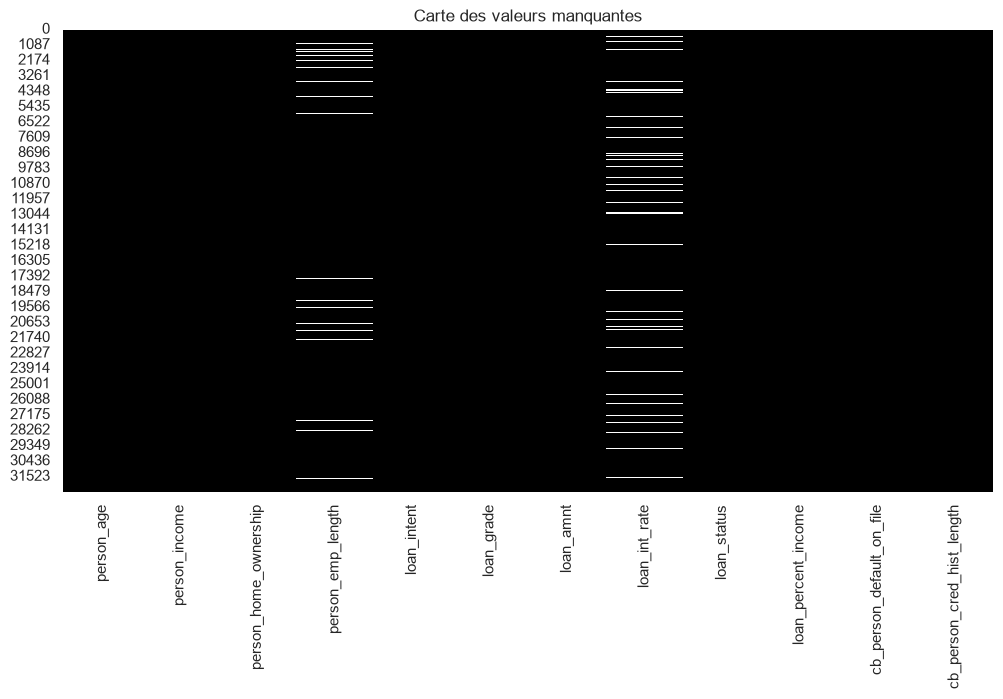

In [3]:
valeurs_manquantes = df.isnull().sum()
print("=== Valeurs manquantes ===")
print(valeurs_manquantes[valeurs_manquantes > 0])

plt.figure()
sns.heatmap(df.isnull(), cbar=False, cmap="gray")
plt.title("Carte des valeurs manquantes")
plt.savefig(RACINE / "images" / "01_valeurs_manquantes.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


=== Repartition 0 = sans risque, 1 = defaut ===
loan_status
0    25473
1     7108
Name: count, dtype: int64
Taux de defaut : 21.82%


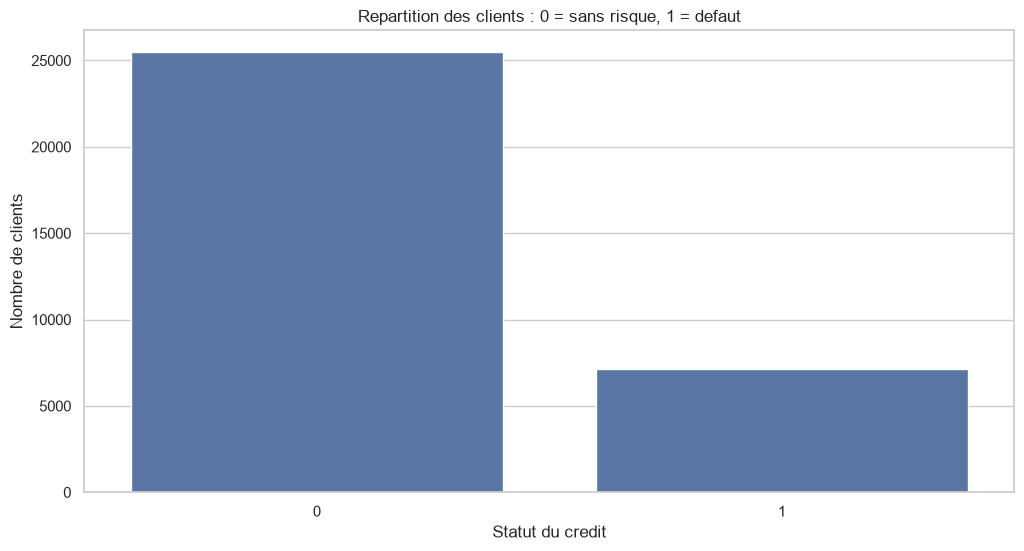

In [4]:
compte_clients = df["loan_status"].value_counts()
taux_defaut = compte_clients[1] / len(df)
print("=== Repartition 0 = sans risque, 1 = defaut ===")
print(compte_clients)
print(f"Taux de defaut : {taux_defaut:.2%}")

plt.figure()
sns.countplot(x="loan_status", data=df)
plt.title("Repartition des clients : 0 = sans risque, 1 = defaut")
plt.xlabel("Statut du credit")
plt.ylabel("Nombre de clients")
plt.savefig(RACINE / "images" / "02_repartition_classes.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


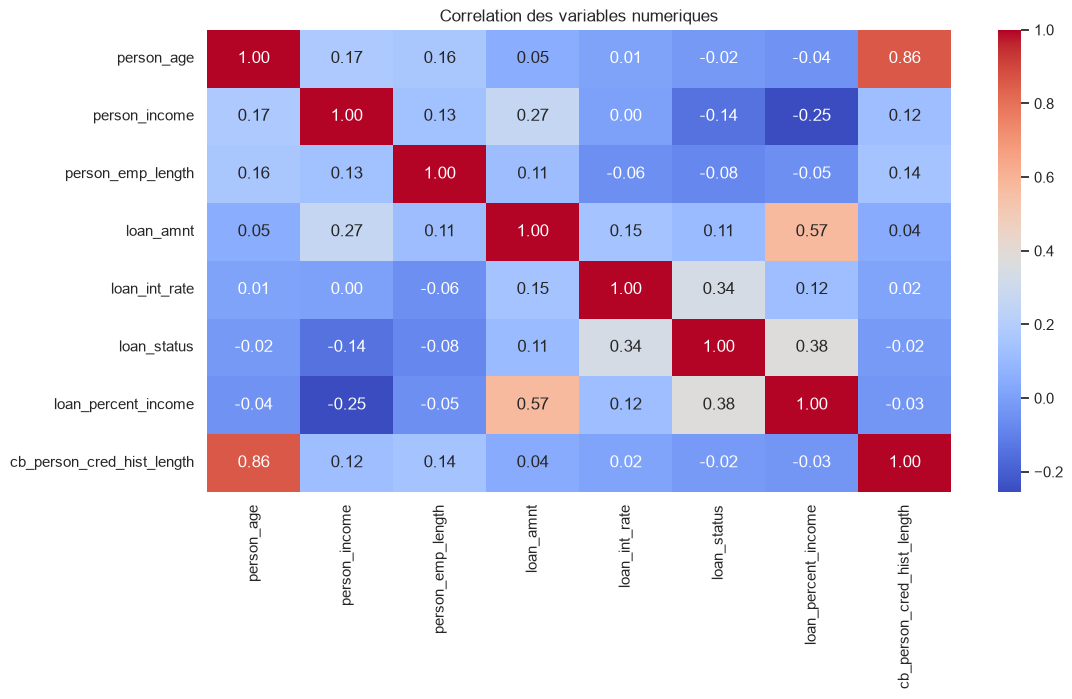

In [5]:
colonnes_numeriques = df.select_dtypes(include="number").columns
matrice_correlation = df[colonnes_numeriques].corr()

plt.figure()
sns.heatmap(matrice_correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation des variables numeriques")
plt.savefig(RACINE / "images" / "03_matrice_correlation.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


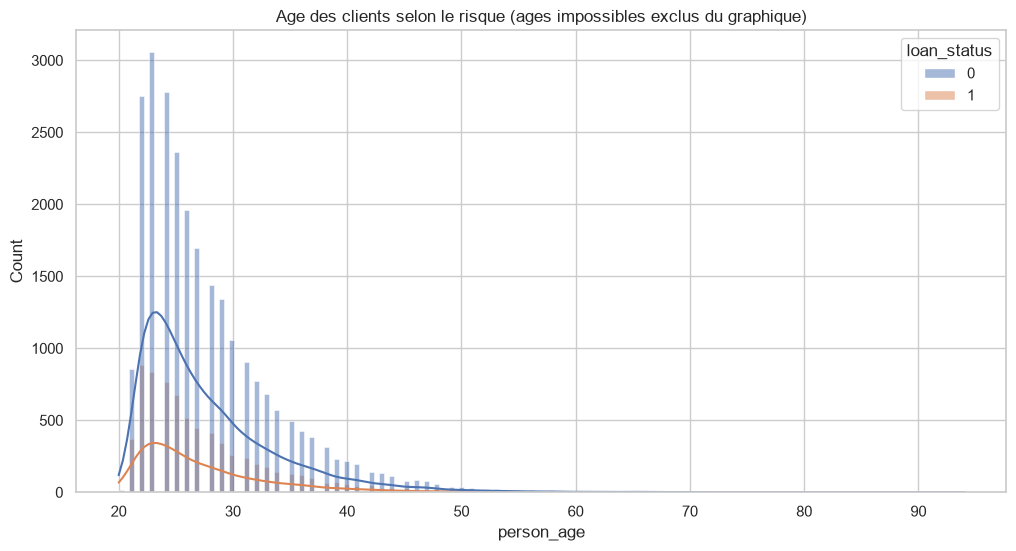

Ages superieurs a 100 ans : 5
Anciennetes superieures a 60 ans : 2


In [6]:
# Les ages > 100 (144, 123) ecrasent l'axe. Ils sont retires a l'etape de nettoyage.
plt.figure()
sns.histplot(data=df.loc[df["person_age"] <= 100], x="person_age", hue="loan_status", kde=True)
plt.title("Age des clients selon le risque (ages impossibles exclus du graphique)")
plt.savefig(RACINE / "images" / "04_distribution_age.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(f"Ages superieurs a 100 ans : {(df['person_age'] > 100).sum()}")
print(f"Anciennetes superieures a 60 ans : {(df['person_emp_length'] > 60).sum()}")



=== Taux de defaut par grade de pret ===
loan_grade     taux  effectif
         A 0.099564     10777
         B 0.162760     10451
         C 0.207340      6458
         D 0.590458      3626
         E 0.644191       964
         F 0.705394       241
         G 0.984375        64


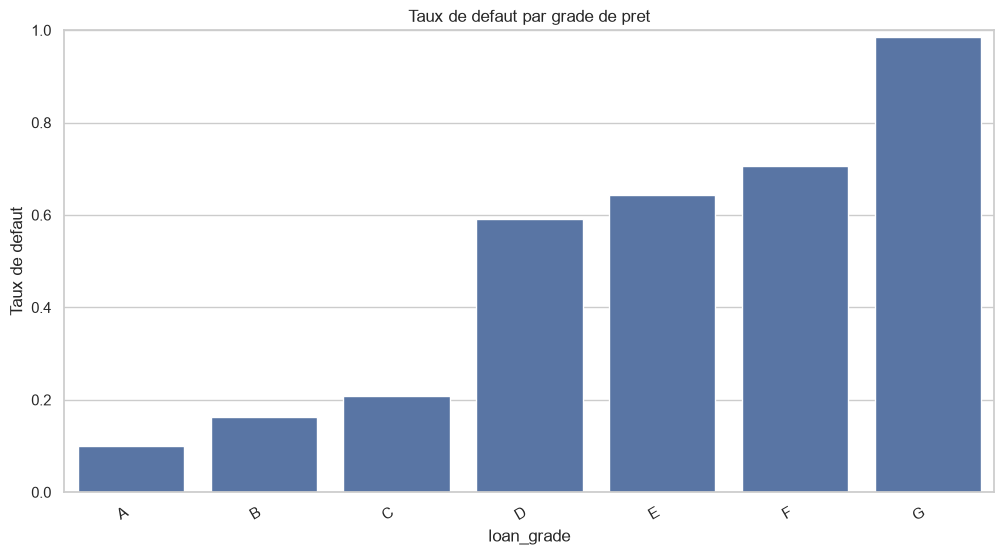


=== Taux de defaut par statut de logement ===
person_home_ownership     taux  effectif
                 RENT 0.315700     16446
                OTHER 0.308411       107
             MORTGAGE 0.125707     13444
                  OWN 0.074690      2584


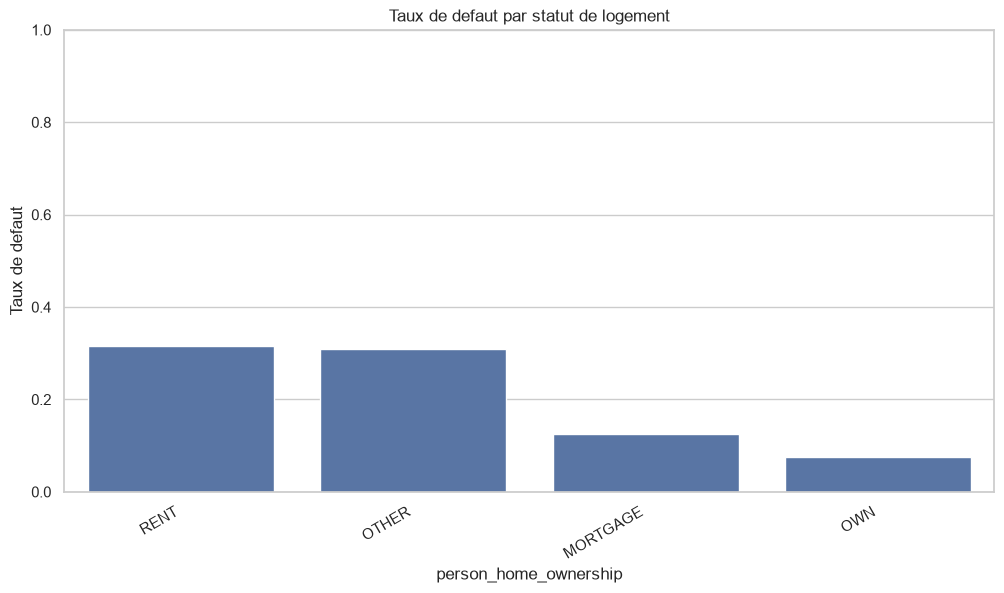


=== Taux de defaut par motif de pret ===
      loan_intent     taux  effectif
DEBTCONSOLIDATION 0.285879      5212
          MEDICAL 0.267007      6071
  HOMEIMPROVEMENT 0.261026      3605
         PERSONAL 0.198877      5521
        EDUCATION 0.172168      6453
          VENTURE 0.148103      5719


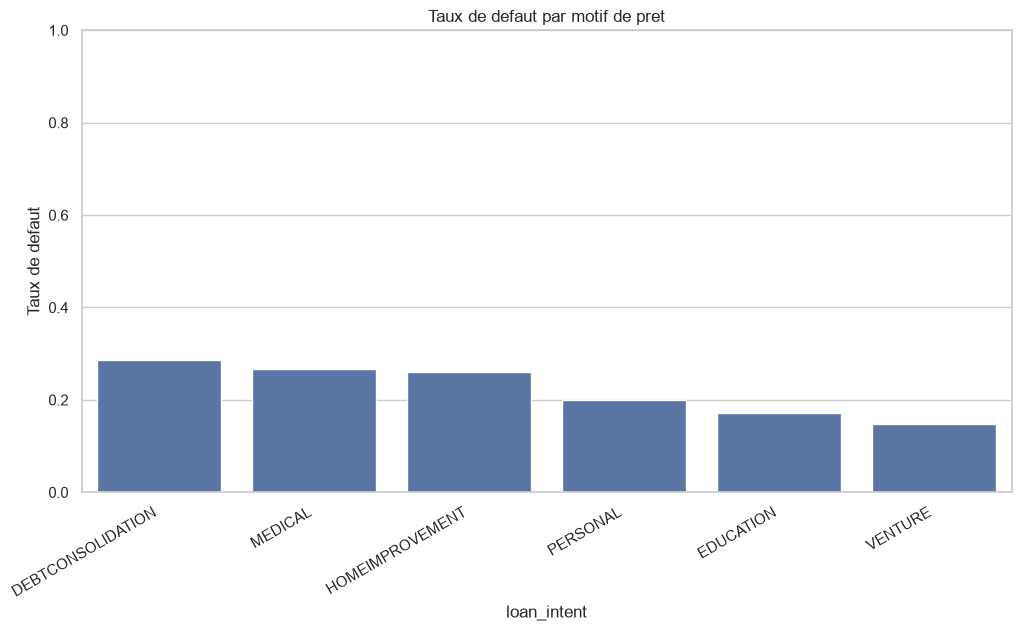

In [7]:
def taux_defaut_par(colonne, fichier, titre, ordre=None):
    tableau = (
        df.groupby(colonne, observed=True)["loan_status"]
        .agg(taux="mean", effectif="size")
        .reset_index()
    )
    if ordre is None:
        tableau = tableau.sort_values("taux", ascending=False)
    else:
        tableau[colonne] = pd.Categorical(tableau[colonne], categories=ordre, ordered=True)
        tableau = tableau.sort_values(colonne)
    print(f"\n=== {titre} ===")
    print(tableau.to_string(index=False))

    plt.figure()
    sns.barplot(data=tableau, x=colonne, y="taux", color="#4c72b0")
    plt.title(titre)
    plt.ylabel("Taux de defaut")
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.savefig(RACINE / "images" / fichier, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


taux_defaut_par(
    "loan_grade",
    "05_taux_defaut_grade.png",
    "Taux de defaut par grade de pret",
    ordre=sorted(df["loan_grade"].unique()),
)
taux_defaut_par(
    "person_home_ownership",
    "06_taux_defaut_logement.png",
    "Taux de defaut par statut de logement",
)
taux_defaut_par(
    "loan_intent",
    "07_taux_defaut_motif.png",
    "Taux de defaut par motif de pret",
)


# Étape 4 : Nettoyage

On retire les dossiers impossibles : âge hors de 18–100 ans, ancienneté négative, supérieure à 60 ans, ou supérieure à l'âge.

Les valeurs manquantes de `person_emp_length` et `loan_int_rate` sont **conservées**. Les supprimer écarte environ 12 % des clients. Elles seront imputées dans le pipeline, avec des médianes calculées sur le train seulement. Le taux d'intérêt manquant est remplacé par la médiane de son grade de prêt.


In [8]:
age_valide = df["person_age"].between(18, 100)
anciennete = df["person_emp_length"]
anciennete_valide = anciennete.isna() | (
    anciennete.between(0, 60) & (anciennete <= df["person_age"])
)

df_nettoye = df.loc[age_valide & anciennete_valide].copy()
print(f"Lignes retirees : {len(df) - len(df_nettoye)}")
print(f"Lignes conservees : {len(df_nettoye)}")
print("Valeurs manquantes encore presentes :")
print(df_nettoye.isnull().sum()[lambda s: s > 0])

X = df_nettoye.drop(columns=["loan_status"])
y = df_nettoye["loan_status"]
colonnes_num = X.select_dtypes(include="number").columns.tolist()
colonnes_cat = X.select_dtypes(exclude="number").columns.tolist()
print(f"Variables numeriques : {colonnes_num}")
print(f"Variables categoriques : {colonnes_cat}")


Lignes retirees : 7
Lignes conservees : 32574
Valeurs manquantes encore presentes :
person_emp_length     895
loan_int_rate        3115
dtype: int64
Variables numeriques : ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
Variables categoriques : ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


# Étape 5 : Jeu de test, puis jeu de validation

- 80 % train / 20 % test. Le test ne sert qu'à la toute fin.
- À l'intérieur du train, 80 % servent à ajuster les modèles et 20 % à les comparer.

`stratify` garde la même proportion de défauts dans chaque partie. Cette proportion reste celle des vrais dossiers, proche de 22 %, parce que SMOTE n'a pas encore été appliqué.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

print(f"Ajustement : {len(X_fit)} | Validation : {len(X_val)} | Test : {len(X_test)}")
print(f"Taux de defaut train : {y_train.mean():.2%}")
print(f"Taux de defaut test  : {y_test.mean():.2%}")


Ajustement : 20847 | Validation : 5212 | Test : 6515
Taux de defaut train : 21.82%
Taux de defaut test  : 21.81%


# Étape 6 : Pipeline

Chaque modèle est un pipeline `imblearn` :

1. `ImputationParGroupe` : médiane du taux par grade, médiane de l'ancienneté
2. Standardisation des variables numériques et encodage one-hot
3. SMOTE, appliqué seulement pendant `fit`
4. Le classifieur

Pendant `predict`, SMOTE est ignoré. Le test et la validation restent déséquilibrés comme dans la réalité. Les étapes sont clonées pour chaque modèle, afin qu'un ajustement n'écrase pas le précédent.


In [10]:
etape_numerique = Pipeline(steps=[
    ("imputation", SimpleImputer(strategy="median")),
    ("standardisation", StandardScaler()),
])
etape_categorique = Pipeline(steps=[
    ("imputation", SimpleImputer(strategy="most_frequent")),
    ("encodage_onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocesseur = ColumnTransformer(transformers=[
    ("num", etape_numerique, colonnes_num),
    ("cat", etape_categorique, colonnes_cat),
])


def construire_pipeline(estimateur):
    return PipelineImb(steps=[
        ("imputation", ImputationParGroupe()),
        ("preprocesseur", clone(preprocesseur)),
        ("smote", SMOTE(random_state=42)),
        ("classifieur", estimateur),
    ])


liste_modeles = {
    "RegLog": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42, n_jobs=1),
    "SVM": SVC(random_state=42, cache_size=1000),
    "XGBoost": xgb.XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=1,
        tree_method="hist",
    ),
}

grilles = {
    "RegLog": {"classifieur__C": [0.1, 1.0, 10.0]},
    "RandomForest": {
        "classifieur__n_estimators": [100, 200],
        "classifieur__max_depth": [10, 20, None],
    },
    "SVM": {"classifieur__C": [0.5, 1.0, 2.0]},
    "XGBoost": {
        "classifieur__n_estimators": [100, 200],
        "classifieur__max_depth": [3, 5, 7],
        "classifieur__learning_rate": [0.05, 0.1],
    },
}


# Étape 7 : Comparaison des 4 modèles

Les modèles sont ajustés sur `X_fit` et notés sur `X_val`. Le test n'est pas lu ici.

Le critère de sélection est l'AUC ROC sur la validation. Le F1, le rappel et la précision du défaut sont affichés pour la lecture métier : le rappel mesure la part des vrais défauts que le modèle retrouve.


RegLog        F1 0.643  AUC 0.878  rappel 0.786


RandomForest  F1 0.826  AUC 0.934  rappel 0.740


SVM           F1 0.759  AUC 0.916  rappel 0.766


XGBoost       F1 0.828  AUC 0.945  rappel 0.738

=== Scores sur le jeu de validation (modeles non optimises) ===


,f1,precision_defaut,rappel_defaut,roc_auc
XGBoost,0.828,0.944,0.738,0.945
RandomForest,0.826,0.935,0.740,0.934
SVM,0.759,0.753,0.766,0.916
RegLog,0.643,0.544,0.786,0.878


Modele retenu pour l'optimisation : XGBoost


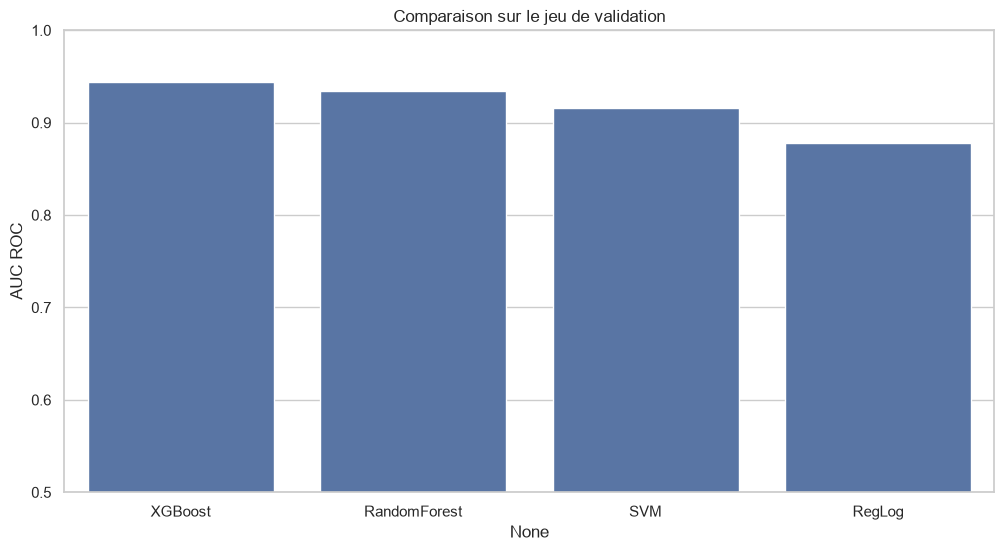

In [11]:
def scores_positifs(modele, donnees):
    if hasattr(modele, "predict_proba"):
        classes = list(modele.named_steps["classifieur"].classes_)
        indice = classes.index(1)
        return modele.predict_proba(donnees)[:, indice]
    return modele.decision_function(donnees)


scores_validation = {}
for nom, estimateur in liste_modeles.items():
    pipeline = construire_pipeline(estimateur)
    pipeline.fit(X_fit, y_fit)
    y_pred = pipeline.predict(X_val)
    y_score = scores_positifs(pipeline, X_val)
    fpr, tpr, _ = roc_curve(y_val, y_score)
    scores_validation[nom] = {
        "f1": f1_score(y_val, y_pred, zero_division=0),
        "precision_defaut": precision_score(y_val, y_pred, zero_division=0),
        "rappel_defaut": recall_score(y_val, y_pred, zero_division=0),
        "roc_auc": auc(fpr, tpr),
    }
    print(
        f"{nom:12}  F1 {scores_validation[nom]['f1']:.3f}  "
        f"AUC {scores_validation[nom]['roc_auc']:.3f}  "
        f"rappel {scores_validation[nom]['rappel_defaut']:.3f}"
    )

tableau_validation = (
    pd.DataFrame.from_dict(scores_validation, orient="index")
    .sort_values("roc_auc", ascending=False)
)
print("\n=== Scores sur le jeu de validation (modeles non optimises) ===")
display(tableau_validation.round(3))

nom_meilleur = tableau_validation["roc_auc"].idxmax()
print(f"Modele retenu pour l'optimisation : {nom_meilleur}")

plt.figure()
sns.barplot(
    x=tableau_validation.index,
    y=tableau_validation["roc_auc"],
    color="#4c72b0",
)
plt.ylim(0.5, 1)
plt.ylabel("AUC ROC")
plt.title("Comparaison sur le jeu de validation")
plt.savefig(RACINE / "images" / "08_comparaison_validation.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# Étape 8 : Optimisation du modèle retenu

La grille est cherchée par validation croisée stratifiée à 3 plis, **sur le train complet**. Le critère est l'AUC ROC. `refit=True` réajuste le meilleur réglage sur tout le train.

SMOTE et l'imputation sont dans le pipeline, donc chaque pli apprend ses propres médianes et ses propres exemples synthétiques. Le pli de contrôle n'est pas rééquilibré.


In [12]:
recherche = GridSearchCV(
    estimator=construire_pipeline(clone(liste_modeles[nom_meilleur])),
    param_grid=grilles[nom_meilleur],
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring="roc_auc",
    n_jobs=-1,
    refit=True,
)
recherche.fit(X_train, y_train)
modele_final = recherche.best_estimator_

print("=== Meilleurs hyperparametres ===")
print(recherche.best_params_)
print(f"AUC ROC moyenne en validation croisee : {recherche.best_score_:.4f}")


=== Meilleurs hyperparametres ===
{'classifieur__learning_rate': 0.1, 'classifieur__max_depth': 7, 'classifieur__n_estimators': 200}
AUC ROC moyenne en validation croisee : 0.9403


# Étape 9 : Évaluation sur le test

Cette cellule est la première qui lit `X_test`. Le nombre de lignes prédites doit être égal au nombre de clients de test : SMOTE n'ajoute personne à ce jeu.

L'AUC et le Gini (`2 * AUC - 1`) résument le classement. Le KS est l'écart maximum entre le taux de vrais défauts et le taux de faux défauts le long de la courbe ROC. La courbe de calibration compare la probabilité annoncée à la fréquence réelle.


=== Evaluation du modele optimise sur le test ===
Clients reels dans le test : 6515
Taux de defaut reel du test : 21.81%
              precision    recall  f1-score   support

           0      0.927     0.993     0.959      5094
           1      0.966     0.719     0.824      1421

    accuracy                          0.933      6515
   macro avg      0.946     0.856     0.891      6515
weighted avg      0.935     0.933     0.929      6515

F1 defaut : 0.824
Precision defaut : 0.966
Rappel defaut : 0.719
AUC ROC : 0.943
Gini : 0.886
KS : 0.736


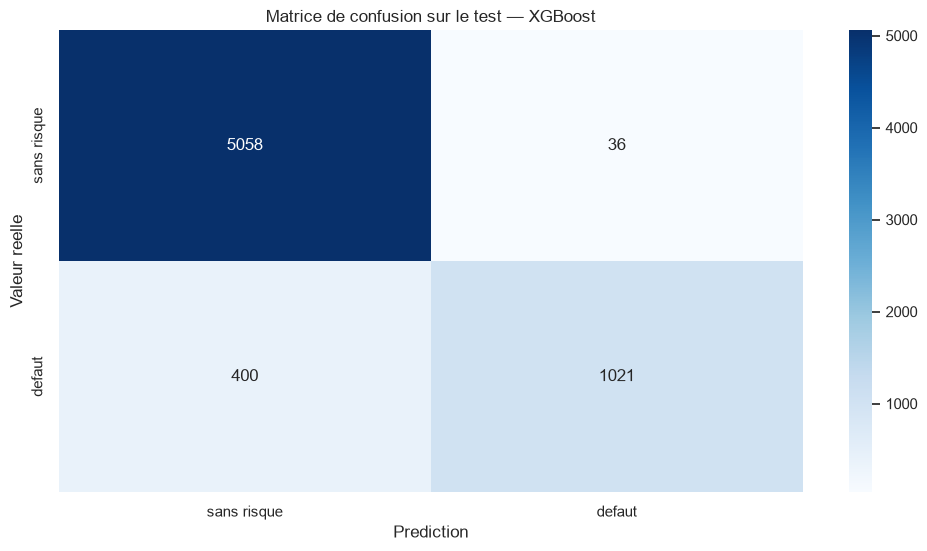

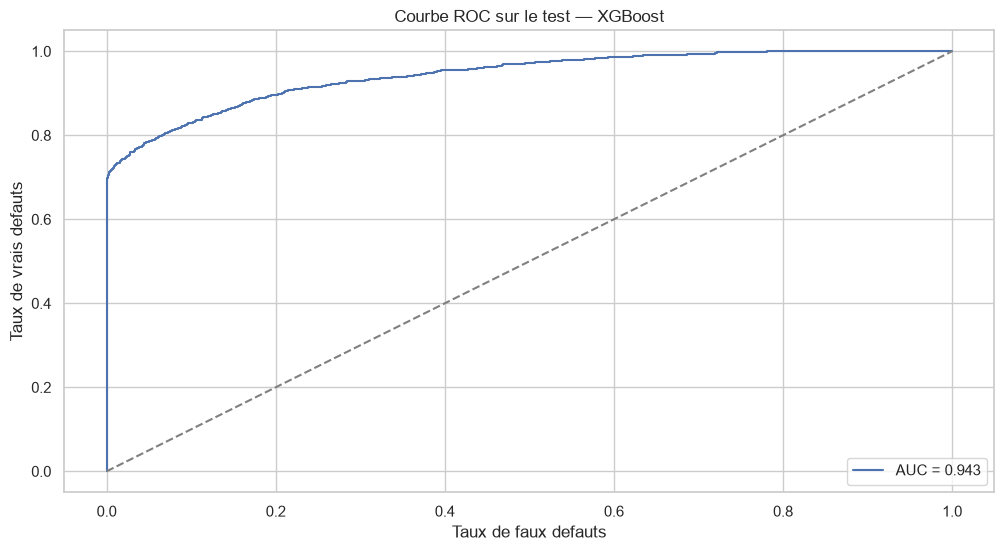

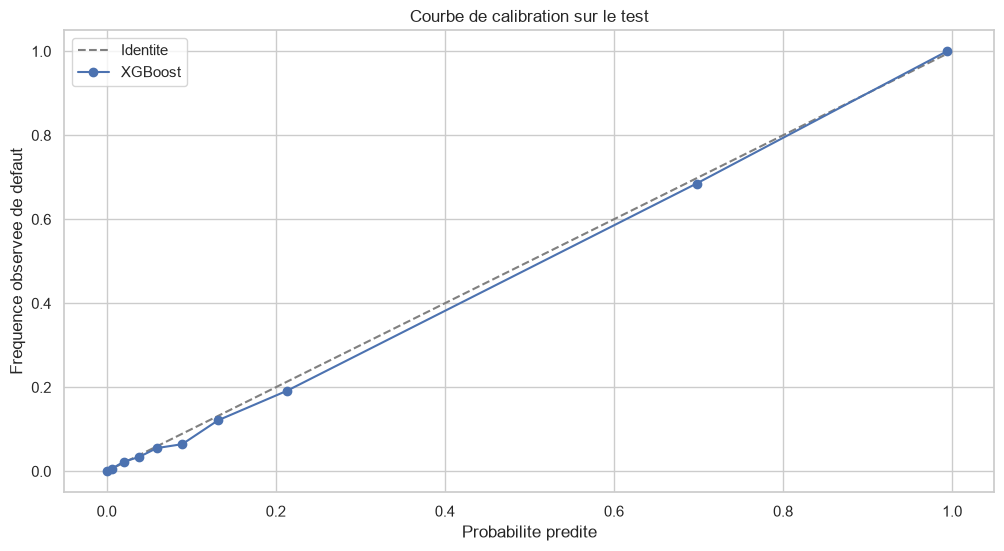

In [13]:
y_pred = modele_final.predict(X_test)
y_score = scores_positifs(modele_final, X_test)
if len(y_pred) != len(X_test):
    raise RuntimeError("Le test a ete reechantillonne : SMOTE ne doit pas s'appliquer au predict.")

fpr, tpr, _ = roc_curve(y_test, y_score)
aire = auc(fpr, tpr)
ks = float(np.max(tpr - fpr))
gini = float(2 * aire - 1)
f1 = f1_score(y_test, y_pred, zero_division=0)
precision = precision_score(y_test, y_pred, zero_division=0)
rappel = recall_score(y_test, y_pred, zero_division=0)

print("=== Evaluation du modele optimise sur le test ===")
print(f"Clients reels dans le test : {len(y_test)}")
print(f"Taux de defaut reel du test : {y_test.mean():.2%}")
print(classification_report(y_test, y_pred, digits=3))
print(f"F1 defaut : {f1:.3f}")
print(f"Precision defaut : {precision:.3f}")
print(f"Rappel defaut : {rappel:.3f}")
print(f"AUC ROC : {aire:.3f}")
print(f"Gini : {gini:.3f}")
print(f"KS : {ks:.3f}")

matrice = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(
    matrice,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["sans risque", "defaut"],
    yticklabels=["sans risque", "defaut"],
)
plt.title(f"Matrice de confusion sur le test — {nom_meilleur}")
plt.xlabel("Prediction")
plt.ylabel("Valeur reelle")
plt.savefig(RACINE / "images" / "09_matrice_confusion.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {aire:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Taux de faux defauts")
plt.ylabel("Taux de vrais defauts")
plt.title(f"Courbe ROC sur le test — {nom_meilleur}")
plt.legend(loc="lower right")
plt.savefig(RACINE / "images" / "10_courbe_roc.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

if hasattr(modele_final, "predict_proba"):
    fraction_reelle, proba_moyenne = calibration_curve(
        y_test, y_score, n_bins=10, strategy="quantile"
    )
    plt.figure()
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Identite")
    plt.plot(proba_moyenne, fraction_reelle, marker="o", label=nom_meilleur)
    plt.xlabel("Probabilite predite")
    plt.ylabel("Frequence observee de defaut")
    plt.title("Courbe de calibration sur le test")
    plt.legend()
    plt.savefig(RACINE / "images" / "11_calibration.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


# Étape 10 : Variables les plus utilisées

Pour un arbre ou un boosting, le graphique lit `feature_importances_`. Pour une régression logistique, il lit la valeur absolue des coefficients. Un SVM à noyau RBF n'expose ni l'un ni l'autre.


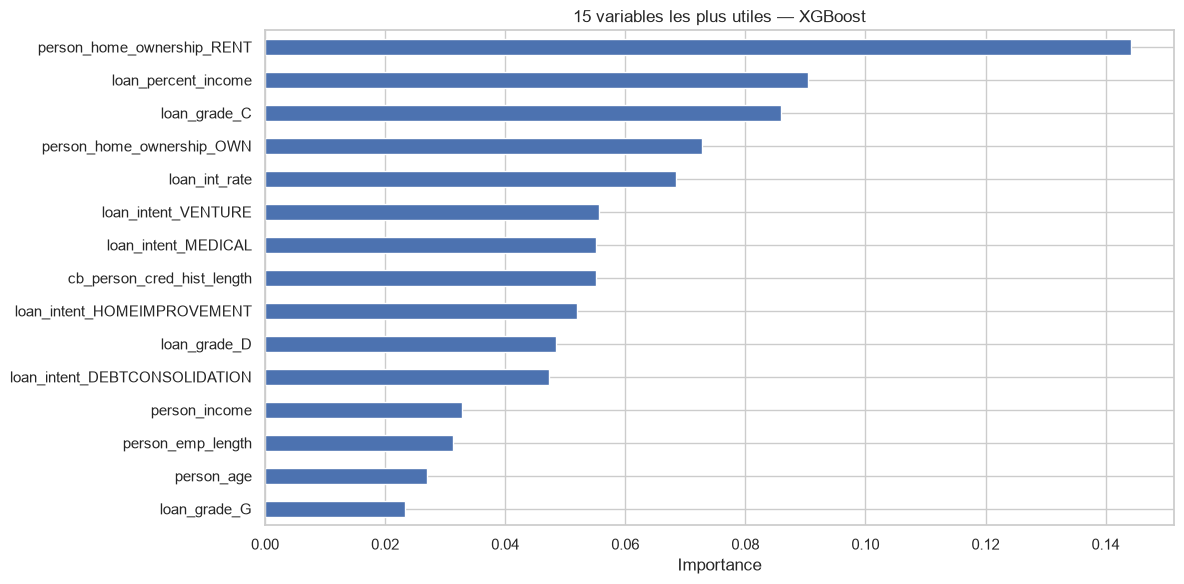

In [14]:
preproc_final = modele_final.named_steps["preprocesseur"]
classifieur = modele_final.named_steps["classifieur"]
noms = [nom.split("__", 1)[-1] for nom in preproc_final.get_feature_names_out()]

if hasattr(classifieur, "feature_importances_"):
    valeurs = np.ravel(classifieur.feature_importances_)
elif hasattr(classifieur, "coef_"):
    valeurs = np.abs(np.ravel(classifieur.coef_))
else:
    valeurs = None
    print("Ce classifieur n'expose pas d'importance de variables exploitable directement.")

if valeurs is not None:
    importance = (
        pd.Series(valeurs, index=noms)
        .sort_values(ascending=False)
        .head(15)
        .sort_values()
    )
    plt.figure()
    importance.plot.barh()
    plt.title(f"15 variables les plus utiles — {nom_meilleur}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig(RACINE / "images" / "12_importance_variables.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


# Étape 11 : Sauvegarde

Le fichier contient le pipeline entier : imputation, prétraitement, SMOTE et modèle optimisé. L'ancien préprocesseur séparé, ajusté sur toute la table, est supprimé pour ne pas être réutilisé par erreur.

Le rechargement fonctionne si le paquet `risque-credit` est installé (`pip install -e . --no-deps`), parce que l'imputation est une classe du projet.


In [15]:
chemin_modele = RACINE / "models" / "modele_risque_credit_final.pkl"
joblib.dump(modele_final, chemin_modele)

ancien_preprocesseur = RACINE / "models" / "preprocesseur.pkl"
if ancien_preprocesseur.exists():
    ancien_preprocesseur.unlink()

print(f"Pipeline enregistre : {chemin_modele}")


Pipeline enregistre : C:\Users\dalex\OneDrive\Desktop\Projet_Risque_Credit\models\modele_risque_credit_final.pkl


# Étape 12 : Prédiction d'un client fictif

La prédiction recharge le fichier du disque. Elle ne réutilise pas l'objet encore en mémoire, pour vérifier que la sauvegarde est complète.


In [16]:
modele_disque = joblib.load(RACINE / "models" / "modele_risque_credit_final.pkl")

client_test = pd.DataFrame({
    "person_age": [34],
    "person_income": [42000],
    "person_home_ownership": ["RENT"],
    "person_emp_length": [6],
    "loan_intent": ["MEDICAL"],
    "loan_grade": ["C"],
    "loan_amnt": [8500],
    "loan_int_rate": [11.2],
    "loan_percent_income": [0.2],
    "cb_person_default_on_file": ["N"],
    "cb_person_cred_hist_length": [12],
})

prediction = int(modele_disque.predict(client_test)[0])
score_client = scores_positifs(modele_disque, client_test)[0]

print("=== Prediction du client fictif (modele recharge depuis le disque) ===")
if prediction == 1:
    print("Conclusion : client a risque de defaut")
else:
    print("Conclusion : client classe sans defaut")

if hasattr(modele_disque, "predict_proba"):
    print(f"Probabilite de defaut estimee : {float(score_client):.2%}")
else:
    print(f"Score de decision (pas une probabilite) : {float(score_client):.3f}")


=== Prediction du client fictif (modele recharge depuis le disque) ===
Conclusion : client classe sans defaut
Probabilite de defaut estimee : 7.57%
